# Day 08. Exercise 05
# Clustering

## 0. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

## 1. Preprocessing

1. Read the file [`regression.csv`](https://drive.google.com/file/d/1fzOPkuXoxLleOsvNVCT0m-LKxlid33ma/view?usp=sharing) to a dataframe.
2. Remove the `pageviews`, we will cluster the users only by the number of the commits and their average difference.

In [2]:
df = pd.read_csv("regression.csv")
df.drop('pageviews', axis=1, inplace=True)
print(df.shape)
df.head()

(29, 3)


,uid,num_commits,AVG(diff)
0,user_1,62,-64.400000
1,user_10,20,-74.800000
2,user_14,61,-159.000000
3,user_17,51,-61.600000
4,user_18,5,-5.666667


## 2. KMeans

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters, use `random_state=21` and `n_clusters=3`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `n_clusters` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

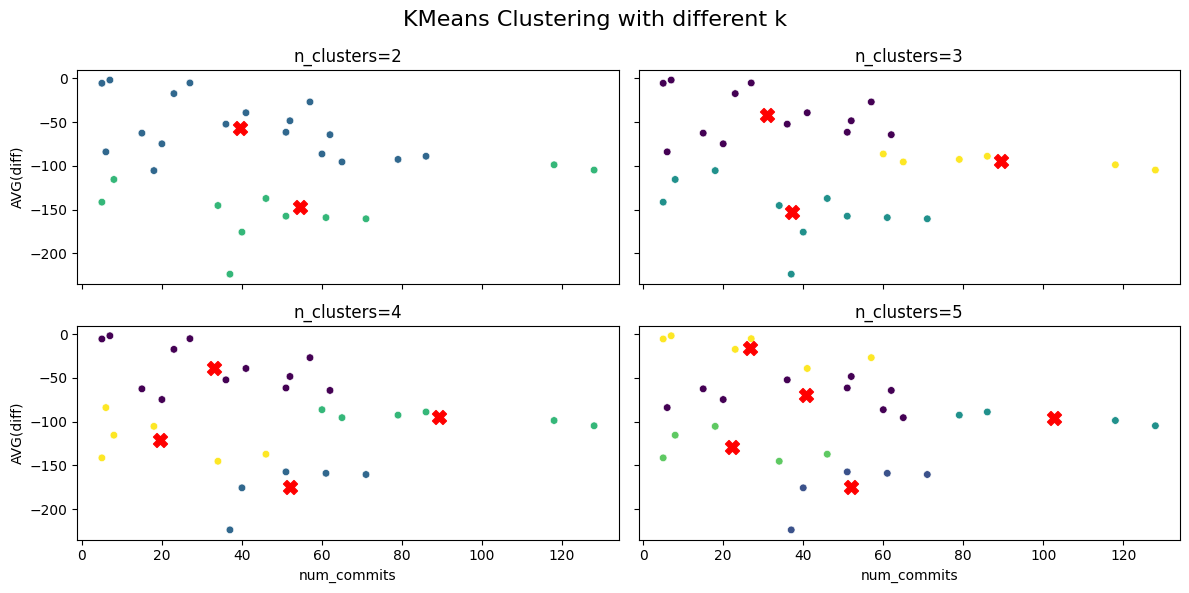

In [3]:
random_state=21
X = df[['num_commits', 'AVG(diff)']]
cluster_range = [2, 3, 4, 5]

fig, axes = plt.subplots(2, 2, figsize=(3 * len(cluster_range), 6), sharex=True, sharey=True)
axes=axes.flatten()

for i, n_clusters in enumerate(cluster_range):
    ax = axes[i]
    
    kmeans = KMeans(random_state=random_state, n_clusters=n_clusters)
    kmeans.fit(X)
    
    df['cluster'] = kmeans.labels_
    centroids = kmeans.cluster_centers_

    sns.scatterplot(data=df,
                    x='num_commits',
                    y='AVG(diff)',
                    hue='cluster',
                    palette='viridis',
                    s=30,
                    ax=ax,
                    legend=False)
    
    ax.scatter(centroids[:, 0], centroids[:, 1], c='red', marker='X', s=100, label='Centroids')
    ax.set_title(f'n_clusters={n_clusters}')

fig.suptitle("KMeans Clustering with different k", fontsize=16)
plt.tight_layout()
plt.show()

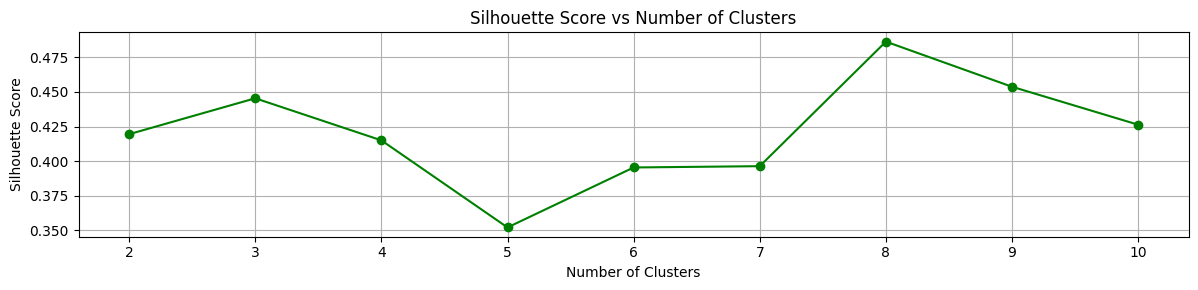

In [4]:
range_n_clusters = range(2, 11)
scores = []

for n_clusters in range_n_clusters:
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state)
    cluster_labels = kmeans.fit_predict(X)
    score = silhouette_score(X, cluster_labels)
    scores.append(score)

plt.figure(figsize=(12, 3))
plt.plot(range_n_clusters, scores, marker='o', linestyle='-', color='green')
plt.title('Silhouette Score vs Number of Clusters')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.xticks(range_n_clusters)
plt.tight_layout()
plt.show()

In [5]:
print(f"The best n_clusters=8, silhouette_score={scores[6]}.")

The best n_clusters=8, silhouette_score=0.48638087320227846.


## 3. DBSCAN

1. Check the documentation about how this algorithm works.
2. Use this algorithm to create clusters with `eps=20` and `min_samples=2`.
3. Visualize the data on a `scatter plot`.
4. Try different values of `eps` and `min_samples` and see how your plot will change.
5. Calculate the `silhouette_score` (check the docs about the metric).

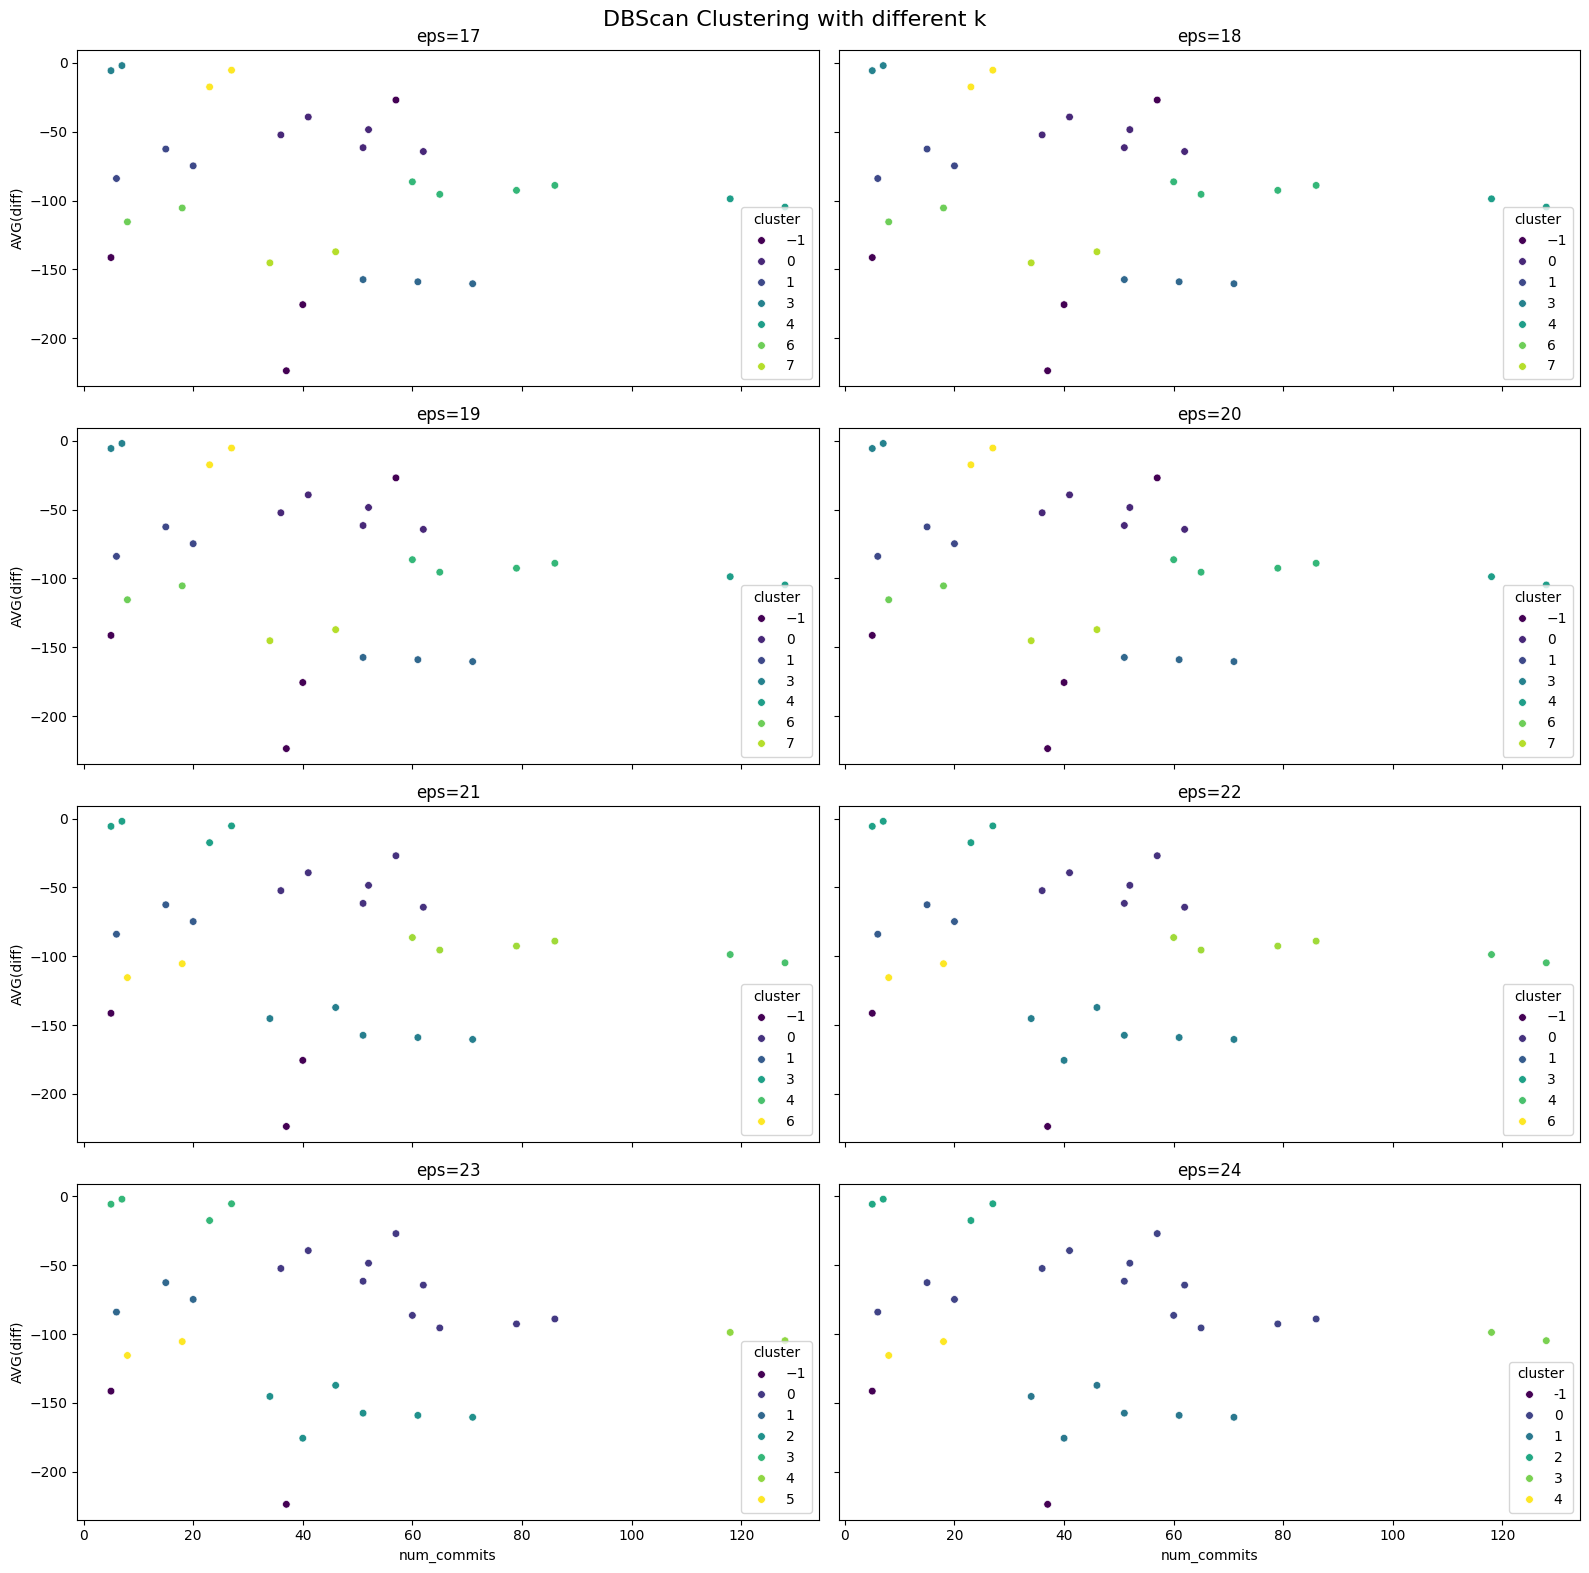

In [6]:
eps_range=[17, 18, 19, 20, 21, 22, 23, 24]
min_samples=2

fig, axes = plt.subplots(4, 2, figsize=(2 * len(eps_range), 16), sharex=True, sharey=True)
axes = axes.flatten()

for i, eps in enumerate(eps_range):
    ax = axes[i]
    
    db = DBSCAN(eps=eps, min_samples=min_samples)
    db.fit(X)
    labels = db.fit_predict(X)
    df['cluster'] = labels
    
    sns.scatterplot(data=df,
                    x='num_commits',
                    y='AVG(diff)',
                    hue='cluster',
                    palette='viridis',
                    s=30,
                    ax=ax)
    
    ax.set_title(f'eps={eps}')

fig.suptitle("DBScan Clustering with different k", fontsize=16)
plt.tight_layout()
plt.show()

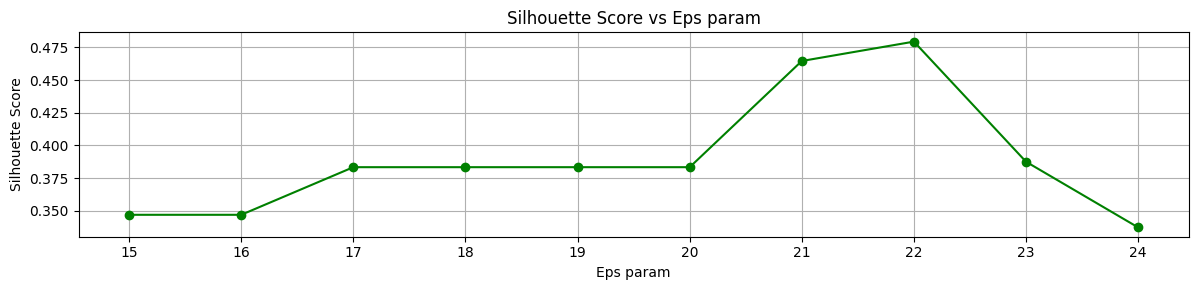

In [7]:
range_eps = range(15, 25)
scores = []

for eps in range_eps:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)

plt.figure(figsize=(12, 3))
plt.plot(range_eps, scores, marker='o', linestyle='-', color='green')
plt.title('Silhouette Score vs Eps param')
plt.xlabel('Eps param')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.xticks(range_eps)
plt.tight_layout()
plt.show()

In [8]:
print(f"The best eps=22, silhouette_score={scores[7]}.")

The best eps=22, silhouette_score=0.4794129092034348.


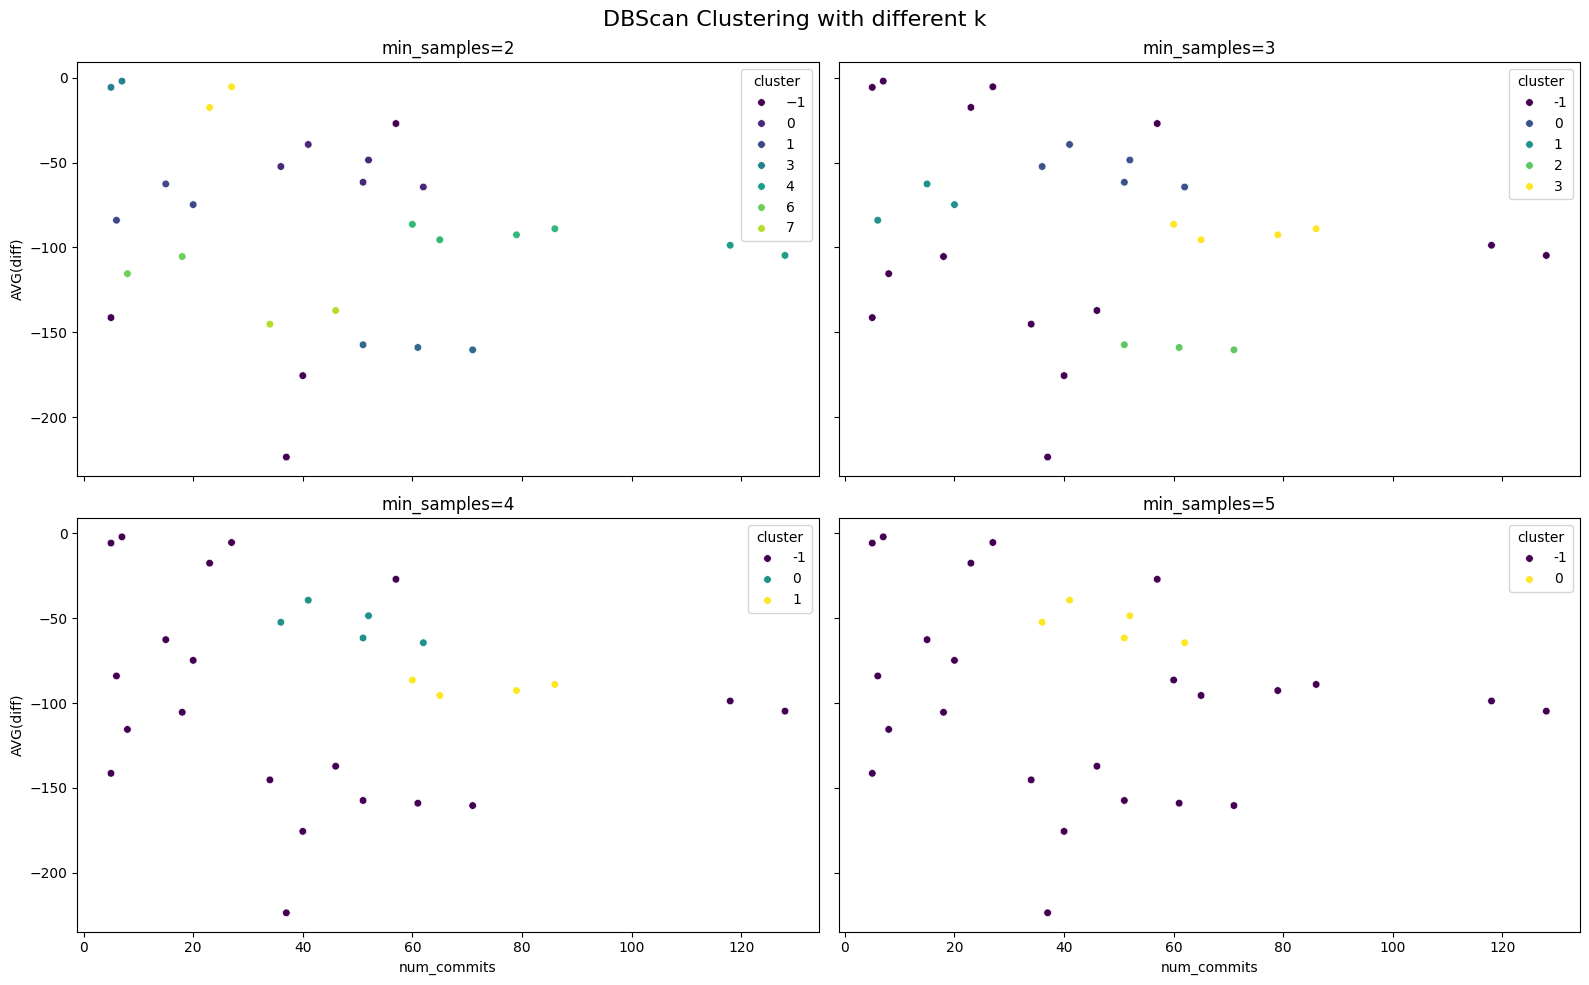

In [9]:
min_samples_range=[2, 3, 4, 5]
eps=20

fig, axes = plt.subplots(2, 2, figsize=(2 * len(eps_range), 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, min_samples in enumerate(min_samples_range):
    ax = axes[i]
    
    db = DBSCAN(eps=eps, min_samples=min_samples)
    db.fit(X)
    labels = db.fit_predict(X)
    df['cluster'] = labels
    
    sns.scatterplot(data=df,
                    x='num_commits',
                    y='AVG(diff)',
                    hue='cluster',
                    palette='viridis',
                    s=30,
                    ax=ax)
    
    ax.set_title(f'min_samples={min_samples}')

fig.suptitle("DBScan Clustering with different k", fontsize=16)
plt.tight_layout()
plt.show()

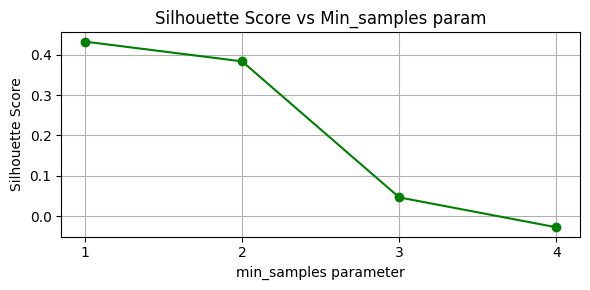

In [10]:
range_min_samples = range(1, 5)
scores = []

for min_samples in range_min_samples:
    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters >= 2: score = silhouette_score(X, labels)
    else: score = float('nan')
    scores.append(score)

plt.figure(figsize=(6, 3))
plt.plot(range_min_samples, scores, marker='o', linestyle='-', color='green')
plt.title('Silhouette Score vs Min_samples param')
plt.xlabel('min_samples parameter')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.xticks(range_min_samples)
plt.tight_layout()
plt.show()


In [11]:
print(f"The best min_samples=1, silhouette_score={scores[0]}.")

The best min_samples=1, silhouette_score=0.4322483665424573.


## 4. Hierarchical (AgglomerativeClustering)

1. Use this algorithm to create clusters with `n_clusters=5`.
2. Visualize the data on a `scatter plot`.
3. Try different values of `n_clusters` and see how your plot will change.
4. Calculate the `silhouette_score`.
5. Visualize the `dendrogram`.

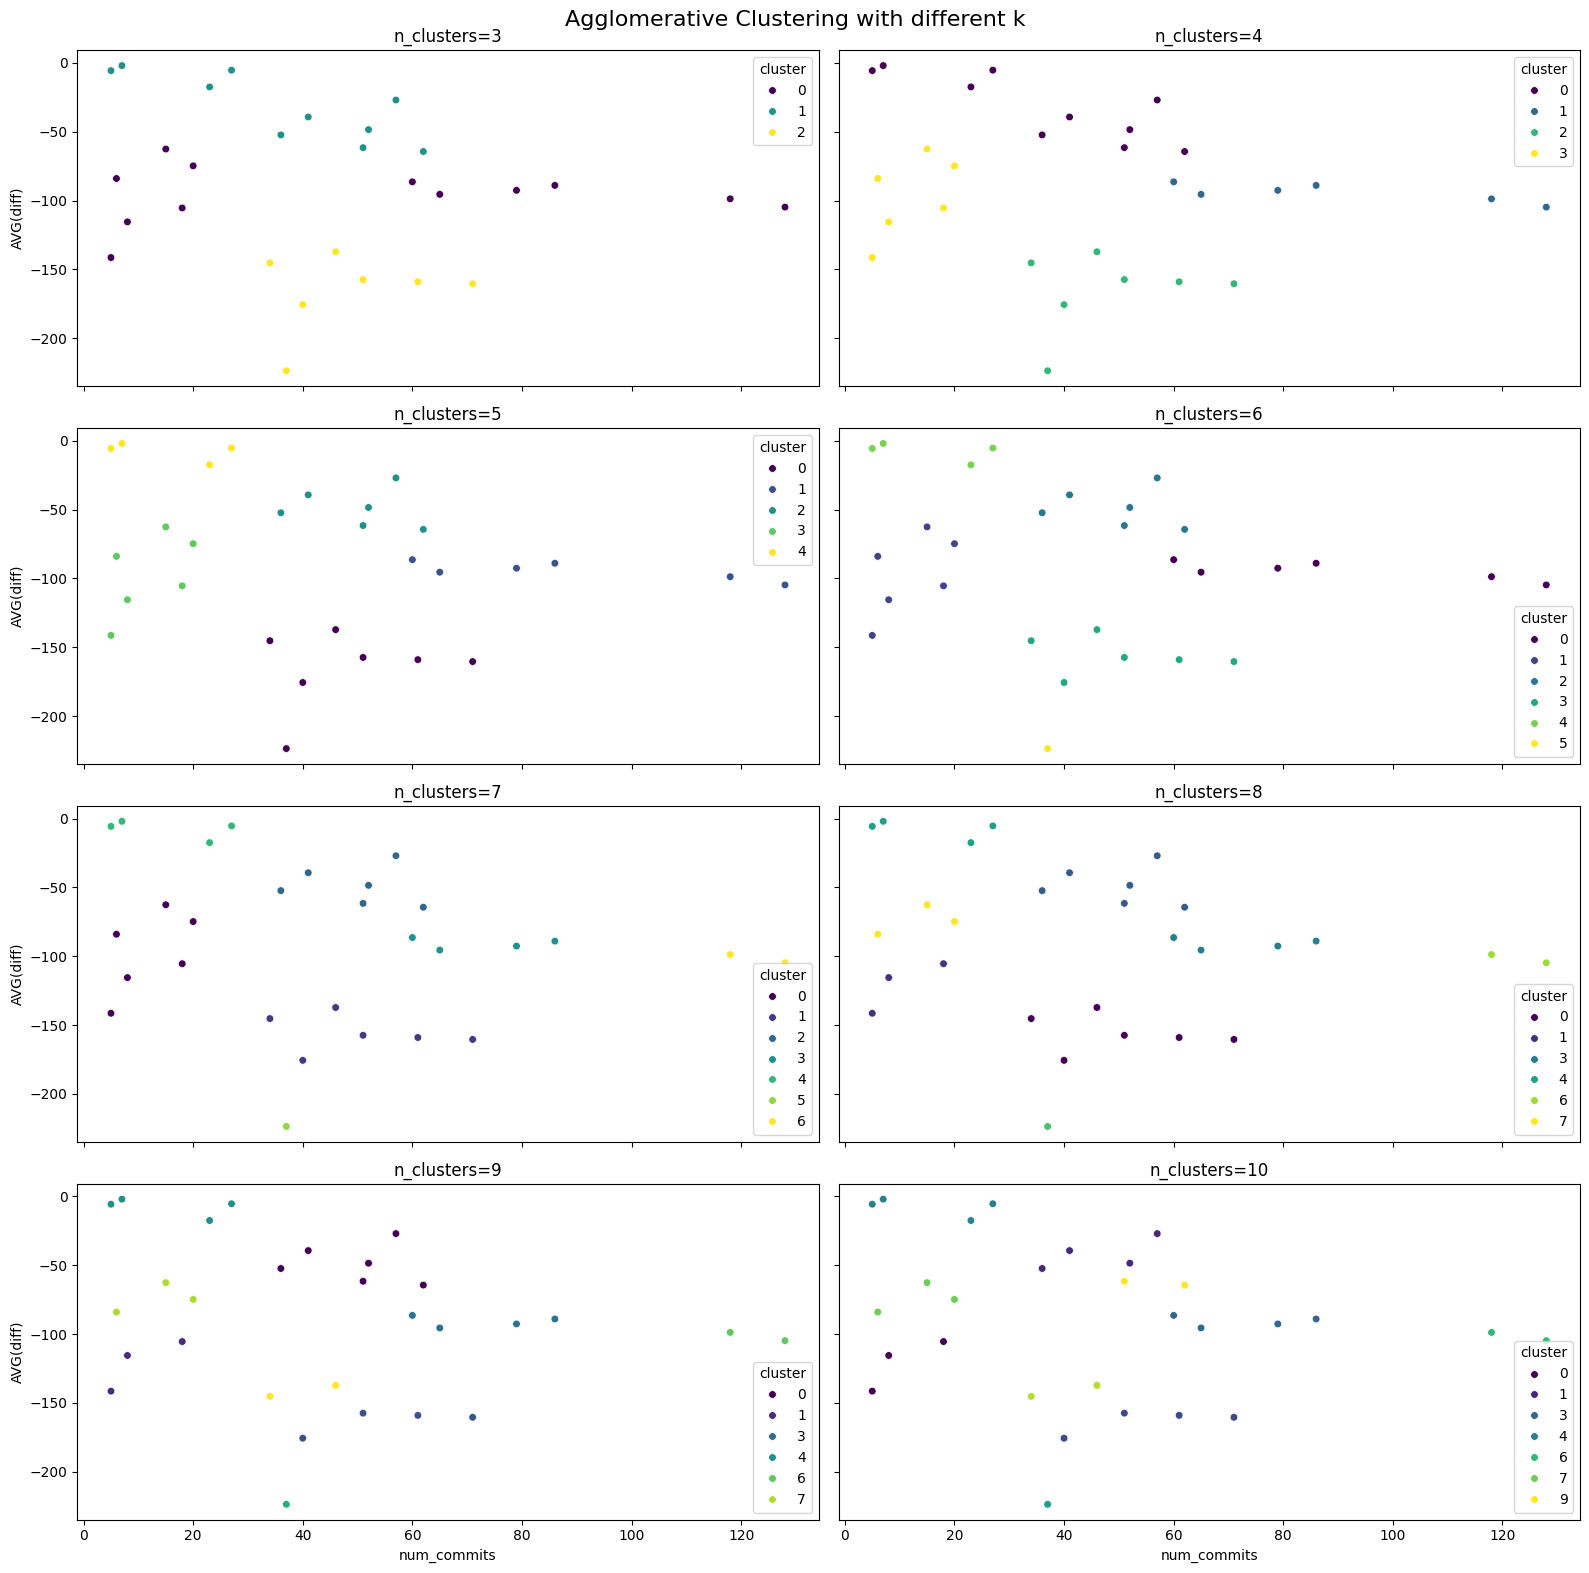

In [12]:
n_clusters_range=[3, 4, 5, 6, 7, 8, 9, 10]

fig, axes = plt.subplots(4, 2, figsize=(2 * len(eps_range), 16), sharex=True, sharey=True)
axes = axes.flatten()

for i, n_clusters in enumerate(n_clusters_range):
    ax = axes[i]
    
    cluster = AgglomerativeClustering(n_clusters=n_clusters).fit(X)
    labels = cluster.fit_predict(X)
    df['cluster'] = labels
    
    sns.scatterplot(data=df,
                    x='num_commits',
                    y='AVG(diff)',
                    hue='cluster',
                    palette='viridis',
                    s=30,
                    ax=ax)
    
    ax.set_title(f'n_clusters={n_clusters}')

fig.suptitle("Agglomerative Clustering with different k", fontsize=16)
plt.tight_layout()
plt.show()

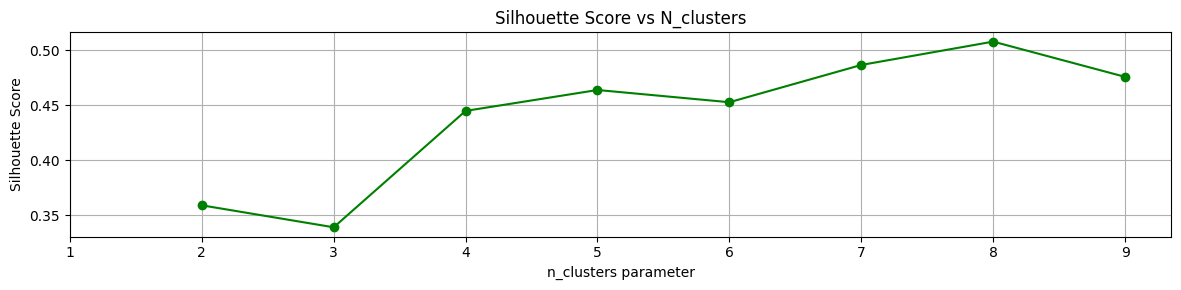

In [13]:
range_n_clusters = range(1, 10)
scores = []

for n_clusters in range_n_clusters:
    cluster = AgglomerativeClustering(n_clusters=n_clusters).fit(X)
    labels = cluster.fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters >= 2: score = silhouette_score(X, labels)
    else: score = float('nan')
    scores.append(score)

plt.figure(figsize=(12, 3))
plt.plot(range_n_clusters, scores, marker='o', linestyle='-', color='green')
plt.title('Silhouette Score vs N_clusters')
plt.xlabel('n_clusters parameter')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.xticks(range_n_clusters)
plt.tight_layout()
plt.show()

In [14]:
print(f"The best n_clusters=8, silhouette_score={scores[7]}.")

The best n_clusters=8, silhouette_score=0.50779855565622.


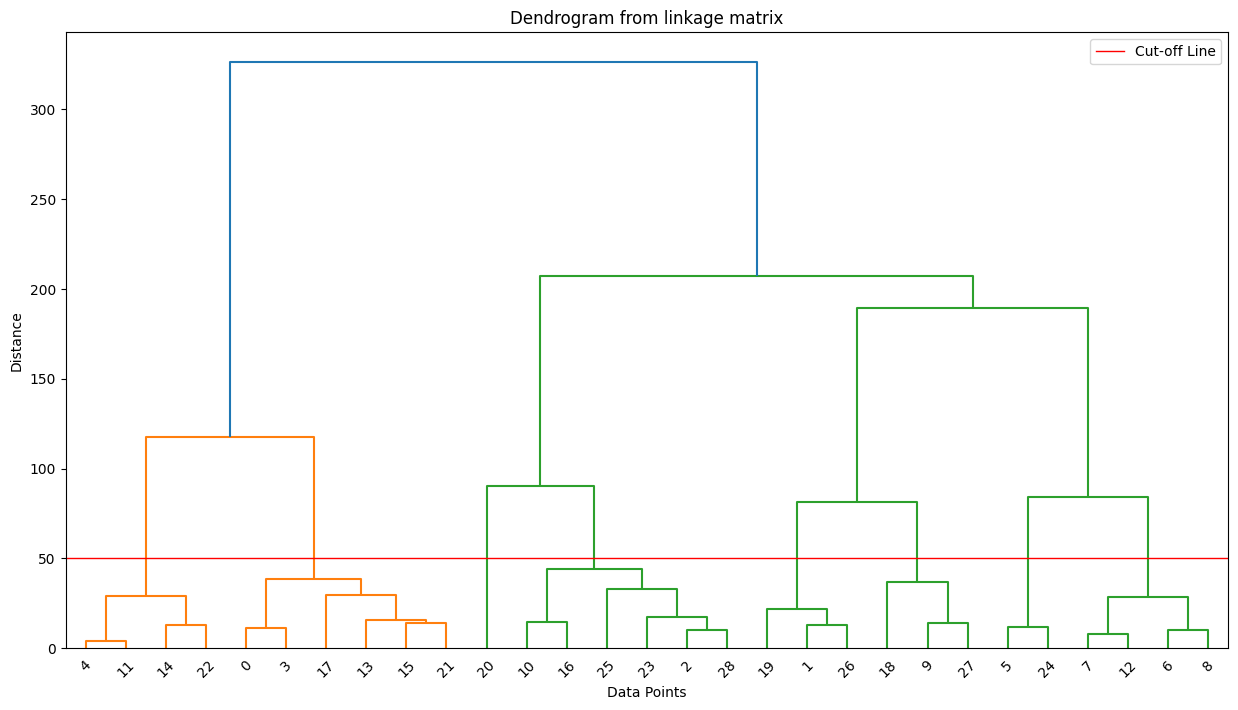

In [20]:
Z = linkage(X, method='ward')
fig = plt.figure(figsize=(15, 8))
dendrogram(Z)
plt.title("Dendrogram from linkage matrix")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.axhline(y=50, color='r', linestyle='-', lw=1, label="Cut-off Line")
plt.legend()
plt.show()